# Simulated Annealing (SA) algorithm aplicado a Travelling Salesman Problem (TSP)

### Optimización: restricción a vecinos cercanos

#### Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.notebook import tqdm

## 1. Preparación del problema

#### Parámetros iniciales

In [ ]:
N = 400 # Número de ciudades
M = 10000 # Pasos de Monte Carlo
alpha = 0.99 # Factor de enfriamiento
c_i = 1.5 # Temperatura inicial
c_f = 0.01 # Temperatura final
#NUEVO################################################################################################################
m_vecinos = 15  # Número de vecinos cercanos a considerar
######################################################################################################################

np.random.seed(47) # Fijamos la semilla para poder reproducir el problema

#### Función para calcular el coste $C(x)$ 

In [3]:
def calcular_coste(ruta, matriz):
    # Desplazamos la ruta una posición para emparejar cada ciudad con la siguiente
    ruta_siguiente = np.roll(ruta, shift=-1)
    # Sumamos las distancias de todas las aristas
    return np.sum(matriz[ruta, ruta_siguiente])

#### Inicialización del problema

In [4]:
#1. MAPA DE CIUDADES: generamos una distribución uniforme de puntos en un cuadro unitario
ciudades = np.random.rand(N, 2) 


#2. MATRIZ DE COSTES: calculamos la distancia euclidiana entre cada par de ciudades (i,j)
diferencias = ciudades[:, np.newaxis, :] - ciudades[np.newaxis, :, :] #np.nwnewaxis añade una dimensión para permitir la resta entre cada par de puntos
matriz_costes = np.sqrt(np.sum(diferencias**2, axis=-1))

# Aseguramos que la diagonal sea 0
np.fill_diagonal(matriz_costes, 0)


#3. RUTA INICIAL: generamos una ruta aleatoria que pase por todas las ciudades
#np.random.permutation genera una permutación aleatoria de los números del 0 al N-1, que representarán el orden de las ciudades en la ruta
ruta_inicial = np.random.permutation(N) 


#4. COSTE INICIAL: calculamos el coste de la ruta inicial
coste_inicial = calcular_coste(ruta_inicial, matriz_costes)
print(f"Coste inicial: {coste_inicial:.2f}")

Coste inicial: 208.92


#### Representación del estado inicial

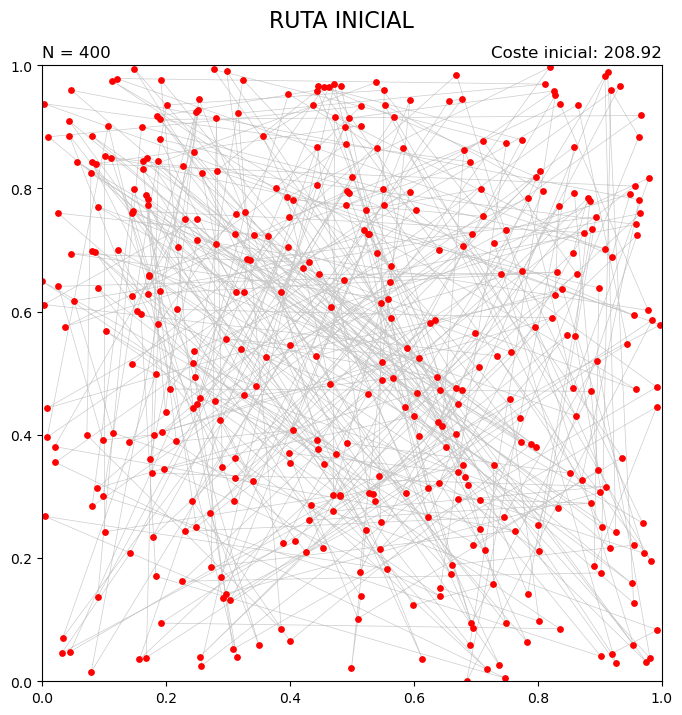

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(ciudades[:, 0], ciudades[:, 1], c='red', s=15, zorder=2, label='Ciudades')

# Para dibujar la ruta cerrada de forma continua, añadimos el primer nodo al final del array
ruta_dibujo = np.append(ruta_inicial, ruta_inicial[0])
plt.plot(ciudades[ruta_dibujo, 0], ciudades[ruta_dibujo, 1], c='gray', alpha=0.4, linewidth=0.5, zorder=1)

plt.suptitle("RUTA INICIAL", fontsize=16, y=0.95)
plt.title(f"N = {N}", loc="left", fontsize=12)
plt.title(f"Coste inicial: {coste_inicial:.2f}", loc="right", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## 2. Algoritmo de Metrópolis

In [ ]:
# Inicializamos las variables
c = c_i
ruta = ruta_inicial.copy()
coste_actual = coste_inicial

# Vectores para registrar la evolución de las variables durante la simulación
registro_c = []
registro_coste_medio = []
registro_varianza = []

# Guardamos algunas temperaturas y rutas intermedias para visualizarlas después
temperaturas_int = [1.2, 0.5, 0.1]
rutas_int = []

# Calculamos cuántas veces se va a multiplicar por alpha para la barra de progreso
total_iteraciones = math.ceil(math.log(c_f / c_i) / math.log(alpha))

#NUEVO################################################################################################################
# Calculamos los vecindarios para cada ciudad: las 'm_vecinos' ciudades más cercanas a cada ciudad
vecindarios = np.argsort(matriz_costes, axis=1)[:, 1:m_vecinos+1]
# np.argsort ordena las distancias de cada fila de menor a mayor y devuelve los índices.
# Con [:, 1:m_vecinos+1] descartamos la columna 0 (la distancia de una ciudad a sí misma es 0)
######################################################################################################################


with tqdm(total=total_iteraciones, desc="Enfriamiento Térmico") as pbar: # barra de progreso
    while c > c_f:
        # Vector para registrar los costes de esta cadena de Markov a temperatura c
        costes_cadena = np.zeros(M)
        
        for k in range(M):
            #NUEVO################################################################################################################
            #1. Elegimos una posición al azar en la ruta actual
            idx_i = np.random.randint(0, N)
            ciudad_A = ruta[idx_i]
        
            #2. Elegimos la ciudad B estrictamente del vecindario precalculado de la ciudad A
            ciudad_B = np.random.choice(vecindarios[ciudad_A])
        
            #3. Buscamos en qué posición (índice) se encuentra la ciudad B en la ruta actual
            idx_j = np.where(ruta == ciudad_B)[0][0]
        
            #4. Ordenamos los índices para que el 2-OPT funcione correctamente
            if idx_i > idx_j:
                idx_i, idx_j = idx_j, idx_i
            
            # Si son contiguos en el extremo, saltamos para evitar problemas de índices vacíos
            if idx_i == idx_j:
                continue
            
            #5. Aplicamos la inversión 2-OPT habitual
            nueva_ruta = ruta.copy()
            nueva_ruta[idx_i:idx_j+1] = nueva_ruta[idx_i:idx_j+1][::-1]
            ######################################################################################################################

            #6. Evaluación del Coste: calculamos el coste de la nueva propuesta
            nuevo_coste = calcular_coste(nueva_ruta, matriz_costes)
            delta_C = nuevo_coste - coste_actual
            
            #7. Criterio de Aceptación de Metropolis: si el coste mejora (delta_C <= 0) o la probabilidad de Boltzmann lo permite:
            if delta_C <= 0 or np.random.rand() < np.exp(-delta_C / c):
                # Aceptamos la nueva ruta
                ruta = nueva_ruta
                coste_actual = nuevo_coste
                
            # Guardamos el coste del estado actual en la cadena, sea el nuevo aceptado o el anterior que hemos mantenido
            costes_cadena[k] = coste_actual
            
        #8. Fin de la cadena para esta temperatura
        registro_c.append(c)
        # <C> Coste esperado en equilibrio
        registro_coste_medio.append(np.mean(costes_cadena))
        # varianza para el calor específico C = ( <C^2> - <C>^2 ) / c^2
        registro_varianza.append(np.var(costes_cadena))
        

        #9. Guardamos rutas intermedias
        if len(temperaturas_int) > 0 and c <= temperaturas_int[0]:
            rutas_int.append((c, ruta.copy(), coste_actual))
            temperaturas_int.pop(0)  # para no guardar más de una ruta a la misma temperatura

        #10.  Enfriamiento 
        c = c * alpha

        pbar.update(1)

# Guardamos la ruta final optimizada
rutas_int.append((c_f, ruta.copy(), coste_actual))

print(f"SIMULACIÓN TERMINADA")
print(f"Coste inicial: {coste_inicial:.2f}")
print(f"Coste final: {coste_actual:.2f}")

Enfriamiento Térmico:   0%|          | 0/499 [00:00<?, ?it/s]

SIMULACIÓN TERMINADA
Coste inicial: 208.92
Coste final: 15.68


## 3. Resultados

#### Límite a bajas temperaturas y normalización de los datos

In [6]:
# Límite a bajas temperaturas
lim_exp = coste_actual / np.sqrt(N) # C*/sqrt(N)
lim_th = 0.749

print(f"Límite numérico obtenido: {lim_exp:.4f}")
print(f"Límite teórico esperado: {lim_th}")
print(f"Error relativo: {abs(lim_exp - lim_th) / lim_th:.2%}")

# Normalizamos los datos
c_norm = np.array(registro_c) * np.sqrt(N)
coste_norm = np.array(registro_coste_medio) / np.sqrt(N)
calor_esp_norm = np.array(registro_varianza) / (N * np.array(registro_c)**2)  # C = varianza/c^2, y normalizamos por N para comparar con el límite teórico

Límite numérico obtenido: 0.7842
Límite teórico esperado: 0.749
Error relativo: 4.70%


#### Ruta final optimizada

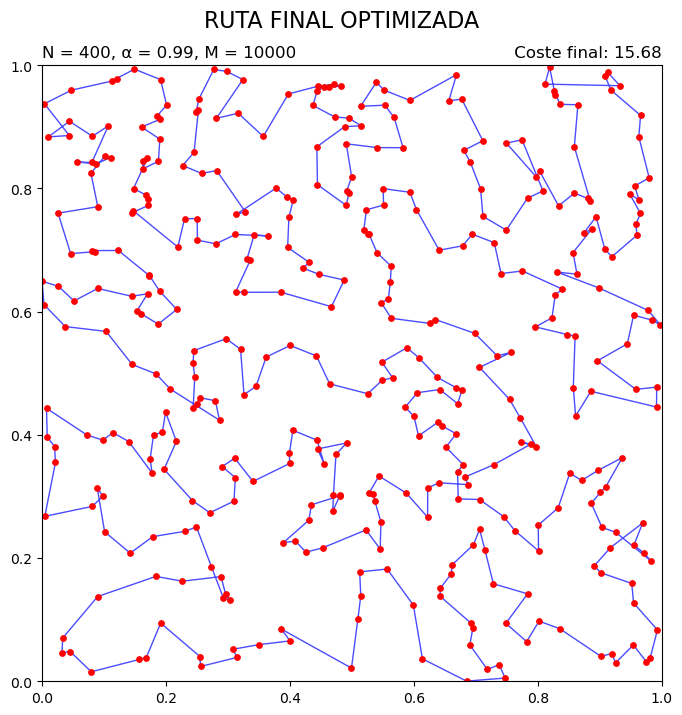

In [7]:
plt.figure(figsize=(8, 8))
plt.scatter(ciudades[:, 0], ciudades[:, 1], c='red', s=15, zorder=2)

# Cerramos la ruta añadiendo el primer nodo al final para que el dibujo sea un ciclo completo
ruta_dibujo = np.append(ruta, ruta[0])

# Dibujamos las líneas de la ruta
plt.plot(ciudades[ruta_dibujo, 0], ciudades[ruta_dibujo, 1], c='blue', alpha=0.7, linewidth=1, zorder=1)

plt.suptitle("RUTA FINAL OPTIMIZADA", fontsize=16, y=0.95)
plt.title(f"N = {N}, α = {alpha:.2f}, M = {M}", loc="left", fontsize=12)
plt.title(f" Coste final: {coste_actual:.2f}", loc="right", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

#### Comparación de rutas para distintas temperaturas

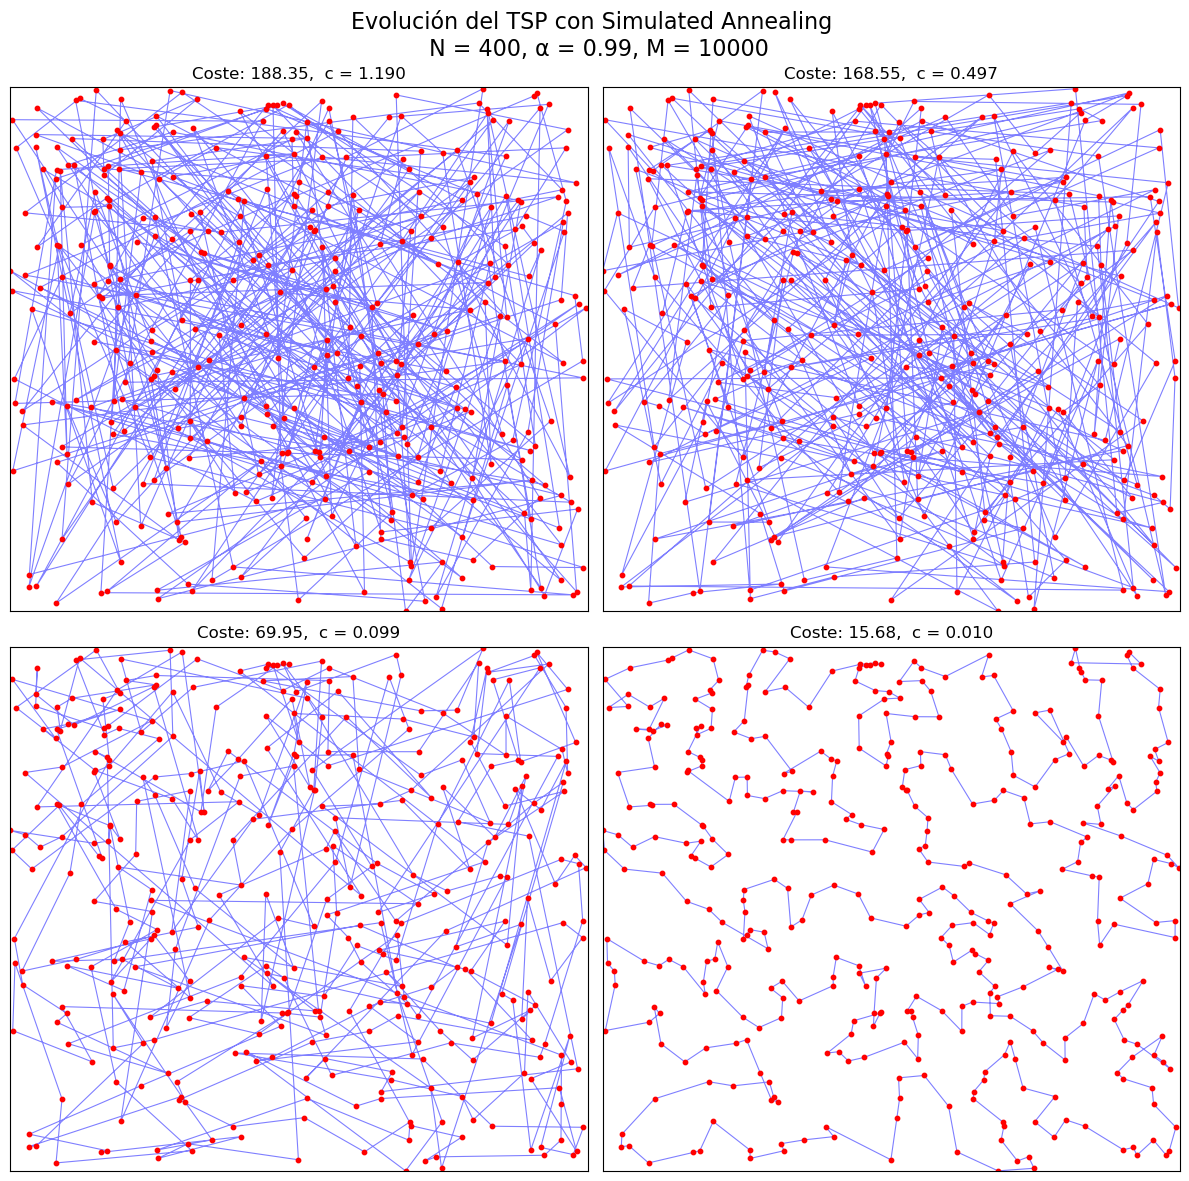

In [8]:
# Creamos una figura grande con 4 subgráficas (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten() 

for i, snap in enumerate(rutas_int[:4]): 
    c_int = snap[0]
    ruta_int = snap[1]
    coste_int = snap[2]
    ax = axs[i]
    
    # Dibujamos las ciudades 
    ax.scatter(ciudades[:, 0], ciudades[:, 1], c='red', s=10, zorder=2)
    # Dibujamos la ruta de ese momento
    ruta_dibujo = np.append(ruta_int, ruta_int[0])
    # Usamos el parámetro 'label' para crear la leyenda 
    ax.plot(ciudades[ruta_dibujo, 0], ciudades[ruta_dibujo, 1], 
            c='blue', alpha=0.5, linewidth=0.8, zorder=1,
            label=f"c = {c_int:.3f}")
    
    ax.set_title(f"Coste: {coste_int:.2f},  c = {c_int:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([]) 
    ax.set_yticks([])
    
    # Añadimos la leyenda en la esquina superior derecha
    # ax.legend(loc="upper right", fontsize=10, framealpha=0.9)

plt.suptitle(f"Evolución del TSP con Simulated Annealing \n N = {N}, α = {alpha:.2f}, M = {M}", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

#### Coste normalizado VS Temperatura

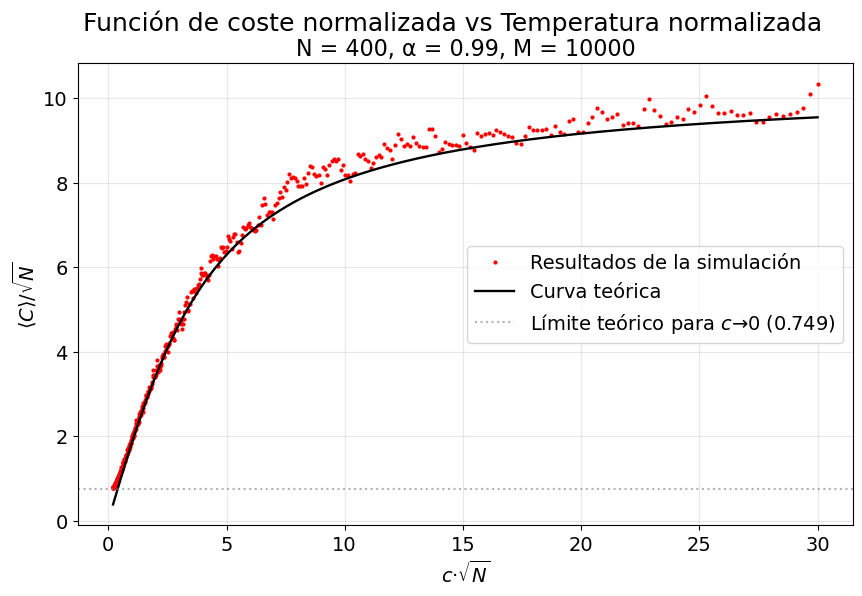

In [9]:
# CURVA EXPERIMENTAL
plt.figure(figsize=(10, 6))
plt.plot(c_norm, coste_norm, 'r.', markersize=4, label='Resultados de la simulación')


# CURVA TEÓRICA

# Nos quedamos con el triangulo superior de la matriz de costes para evitar contar cada distancia dos veces (i,j) y (j,i)
triangular_superior = matriz_costes[np.triu_indices(N, k=1)]
# Cogemos 200 valores (p.ej) de la temperatura para el eje x
c_th = np.linspace(min(registro_c), max(registro_c), 200)
# Inicializamos un vector para guardar los costes teóricos correspondientes a cada temperatura
coste_th = []

for c_i in c_th:
    # eq 37 de Bonomi: <C> = N * <d*exp(-d/c)> / <exp(-d/c)>
    exp_term = np.exp(-triangular_superior / c_i)
    numerador = np.sum(triangular_superior * exp_term)
    denominador = np.sum(exp_term)
    coste_th.append(N * numerador / denominador)


#Normalizamos
c_th_norm = c_th * np.sqrt(N)
coste_th_norm = np.array(coste_th) / np.sqrt(N)

plt.plot(c_th_norm, coste_th_norm, '-', color='black', linewidth=1.7, label='Curva teórica')
plt.axhline(y=lim_th, color='gray', linestyle=':', alpha=0.6, label='Límite teórico para $c → 0$ (0.749)') # Valor teórico esperado cuando c → 0



plt.suptitle("Función de coste normalizada vs Temperatura normalizada", fontsize=18, y=0.97)
plt.title(f"N = {N}, α = {alpha:.2f}, M = {M}", fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.xlabel("$c · \sqrt{N}$", fontsize=14)
plt.ylabel("$\langle C \\rangle / \sqrt{N}$", fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

#### Coste normalizado VS Temperatura --> Zoom en el límite a bajas temperaturas

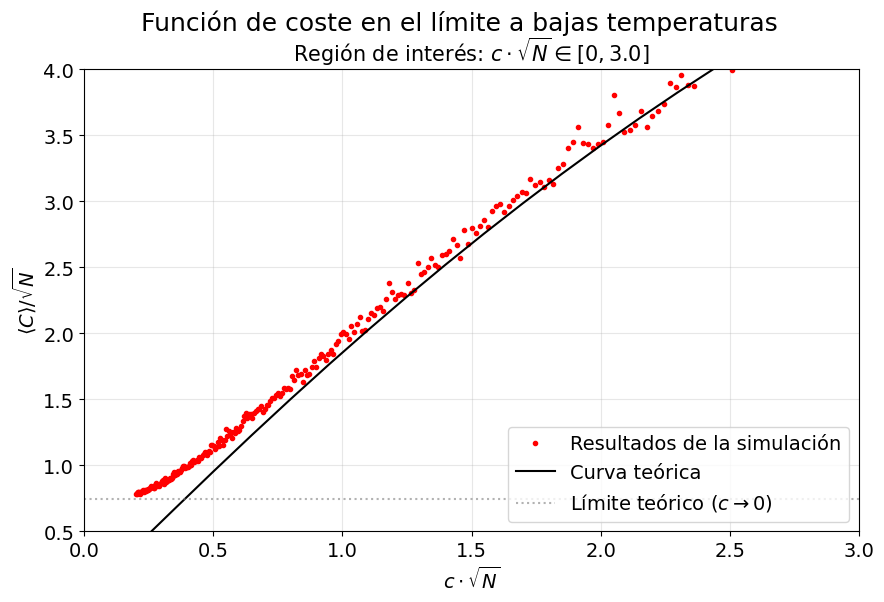

In [10]:
plt.figure(figsize=(10, 6))

# Reutilizamos los datos calculados previamente pero con marcadores más grandes
plt.plot(c_norm, coste_norm, 'r.', markersize=6, label='Resultados de la simulación')
plt.plot(c_th_norm, coste_th_norm, 'k-', linewidth=1.5, label='Curva teórica')
plt.axhline(y=lim_th, color='gray', linestyle=':', alpha=0.6, label=r'Límite teórico ($c \rightarrow 0$)')

# Enfoque exclusivo en el estado de congelación
plt.xlim(0, 3.0)
plt.ylim(0.5, 4.0)

plt.suptitle("Función de coste en el límite a bajas temperaturas", fontsize=18, y=0.98)
plt.title(f"Región de interés: $c \cdot \sqrt{{N}} \in [0, 3.0]$", fontsize=15)
plt.tick_params(axis='both', labelsize=14)
plt.xlabel(r"$c \cdot \sqrt{N}$", fontsize=14)
plt.ylabel(r"$\langle C \rangle / \sqrt{N}$", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

#### Calor específico normalizado VS Temperatura

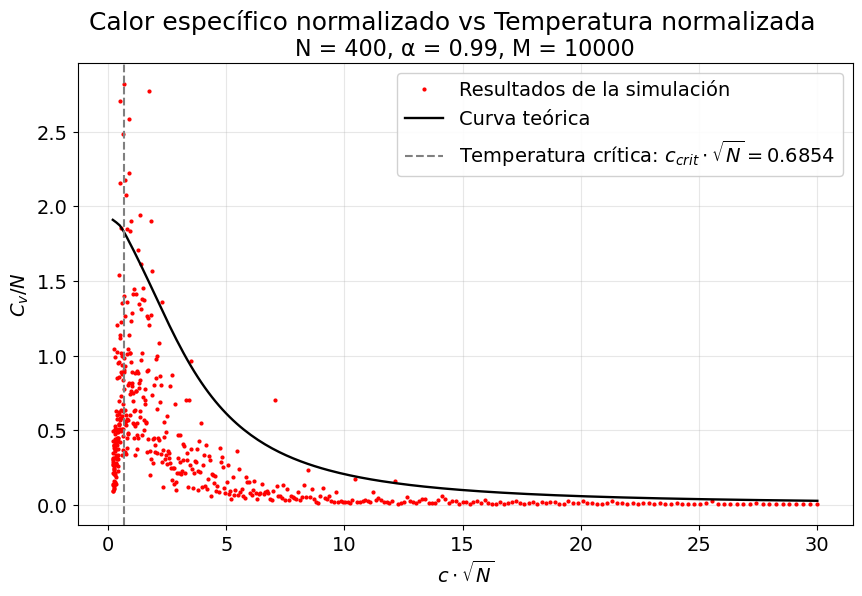

In [11]:
plt.figure(figsize=(10, 6))

# CURVA EXPERIMENTAL
plt.plot(c_norm, calor_esp_norm, 'r.', markersize=4, label='Resultados de la simulación')


# CURVA TEÓRICA
cv_th_norm = []
for c_i in c_th: #C_v = <C^2> - <C>^2 / c^2
    exp_term = np.exp(-triangular_superior / c_i)
    Z = np.sum(exp_term) # denominador

    # Valores esperados de <d> y <d^2>
    d_esp = np.sum(triangular_superior * exp_term) / Z
    d2_esp = np.sum((triangular_superior**2) * exp_term) / Z

    # Varianza de un enlace independiente: <d^2> - <d>^2
    var_d = d2_esp - (d_esp**2)

    # C_v / N = varianza_enlace / c^2
    cv_n = var_d / (c_i**2)
    cv_th_norm.append(cv_n)
cv_th_norm = np.array(cv_th_norm)

plt.plot(c_th_norm, cv_th_norm, '-', color='black', linewidth=1.7, label='Curva teórica')


# Identificación del máximo experimental
idx_max = np.argmax(calor_esp_norm)
c_critica_norm = c_norm[idx_max]
calor_esp_max = calor_esp_norm[idx_max]
plt.axvline(x=c_critica_norm, color='gray', linestyle='--', linewidth=1.5,
            label=f'Temperatura crítica: $c_{{crit}} \cdot \\sqrt{{N}} = {c_critica_norm:.4f}$')


plt.suptitle("Calor específico normalizado vs Temperatura normalizada", fontsize=18, y=0.97)
plt.title(f"N = {N}, α = {alpha:.2f}, M = {M}", fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.xlabel("$c \cdot \sqrt{N}$", fontsize=14)
plt.ylabel("$C_v / N$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=14, framealpha=0.9)
plt.show()